# K-Nearest Neighbors: Estimating Density from Data

## 🔗 Connecting to the tav-hormone story

In the previous notebook, Mr. Tavasoli knew the **true distributions** of the
tav-hormone in girls and boys, so he could compute the optimal decision boundary
analytically (the intersection of the weighted densities).

But in reality, **we never know the true densities**. We only have **samples**:
a dataset of babies with measured hormone levels and known sex.

**Key insight:** the optimal rule was

$$\text{predict the class with the highest } P(\text{class}) \cdot p(x \mid \text{class})$$

If we could *estimate* that quantity from data, we'd have a practical classifier.
**K-Nearest Neighbors (KNN)** does exactly that — implicitly!

## 💡 The intuition

To classify a new point $x$:

1. Look at the $k$ training points **closest** to $x$.
2. Count how many belong to each class.
3. Predict the **majority class**.

Why does this approximate the Bayes rule? Around point $x$, take a small
neighborhood containing the $k$ nearest samples. If $k_{\text{girl}}$ of them are girls, then:

$$\frac{k_{\text{girl}}}{k} \approx P(\text{girl} \mid x)$$

The local **density of points of a class** is proportional to
$P(\text{class}) \cdot p(x \mid \text{class})$ — classes that are more common (higher
prior) and denser near $x$ (higher likelihood) contribute more neighbors.
So the majority vote is a *sample-based estimate of the highest posterior*!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)

# Regenerate the tav-hormone dataset
P_GIRL, P_BOY = 0.7, 0.3
girl_dist = stats.norm(4.0, 1.2)
boy_dist  = stats.norm(7.0, 1.5)

n = 2000
n_girls = int(n * P_GIRL)
X = np.concatenate([girl_dist.rvs(n_girls), boy_dist.rvs(n - n_girls)]).reshape(-1, 1)
y = np.array([0] * n_girls + [1] * (n - n_girls))   # 0 = girl, 1 = boy

## 🤖 KNN with scikit-learn (1D: the hormone example)

In [5]:
n_girls

1400

In [28]:
neighbors_idxs = np.argsort(np.abs(X - 6.5)[:,0])[:20]

In [29]:
y[neighbors_idxs]

array([1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1])

In [32]:
y_train

array([1, 0, 0, ..., 0, 0, 1], shape=(1400,))

In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train, y_train)
print(f"Test accuracy: {knn.score(X_test, y_test):.3f}")

Test accuracy: 0.903


In [40]:
(knn.predict(X_test) == y_test).mean()

np.float64(0.9033333333333333)

## 🗺️ KNN in 2D: decision regions

The real power of KNN shows in higher dimensions. Suppose in 2040, Mr. Tavasoli
discovers a **second hormone**. Now each baby is a point in 2D.

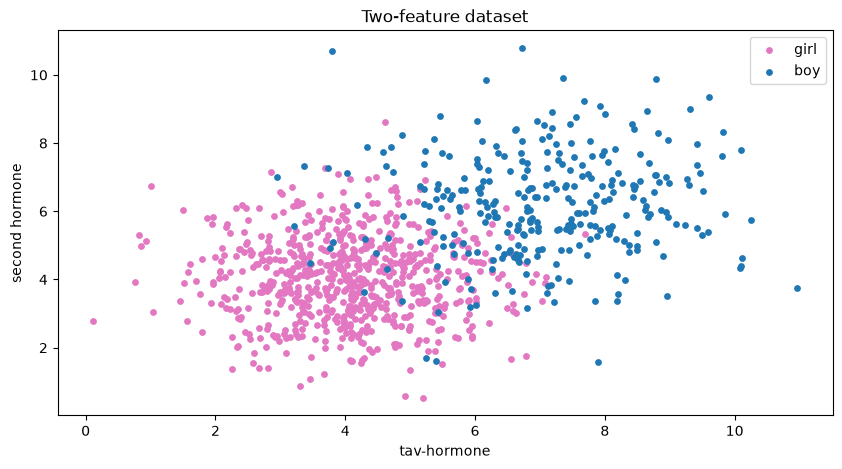

In [41]:
from sklearn.datasets import make_blobs
from matplotlib.colors import ListedColormap

X2, y2 = make_blobs(n_samples=[700, 300], centers=[[4, 4], [7, 6]],
                    cluster_std=[1.2, 1.5], random_state=42)

plt.scatter(X2[y2 == 0, 0], X2[y2 == 0, 1], c="tab:pink", s=15, label="girl")
plt.scatter(X2[y2 == 1, 0], X2[y2 == 1, 1], c="tab:blue", s=15, label="boy")
plt.xlabel("tav-hormone"); plt.ylabel("second hormone")
plt.legend(); plt.title("Two-feature dataset"); plt.show()

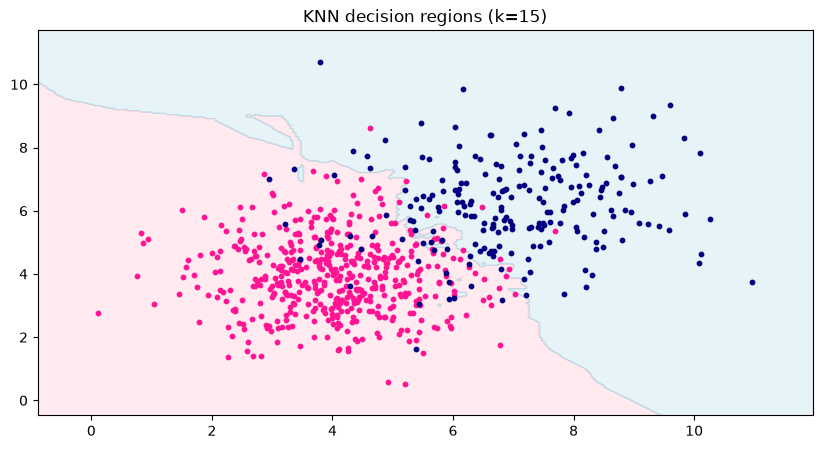

(np.float64(0.9414285714285714), np.float64(0.9266666666666666))

In [53]:
def plot_decision_boundary(model, X, y, title):
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 300),
                         np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(["pink", "lightblue"]))
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c="deeppink", s=10)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c="navy", s=10)
    plt.title(title); plt.show()


X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.3, random_state=0
)

knn2 = KNeighborsClassifier(n_neighbors=5).fit(X2_train, y2_train)
plot_decision_boundary(knn2, X2_train, y2_train, "KNN decision regions (k=15)")



train_acc = (knn2.predict(X2_train) == y2_train).mean()
test_acc = (knn2.predict(X2_test) == y2_test).mean()
train_acc, test_acc

## ⚖️ Choosing k: the bias–variance trade-off

- **Small k** (e.g. k=1): very flexible, follows noise → **overfitting** (high variance).
- **Large k**: very smooth, ignores local structure → **underfitting** (high bias).
- k = n: always predicts the majority class (just the prior!).

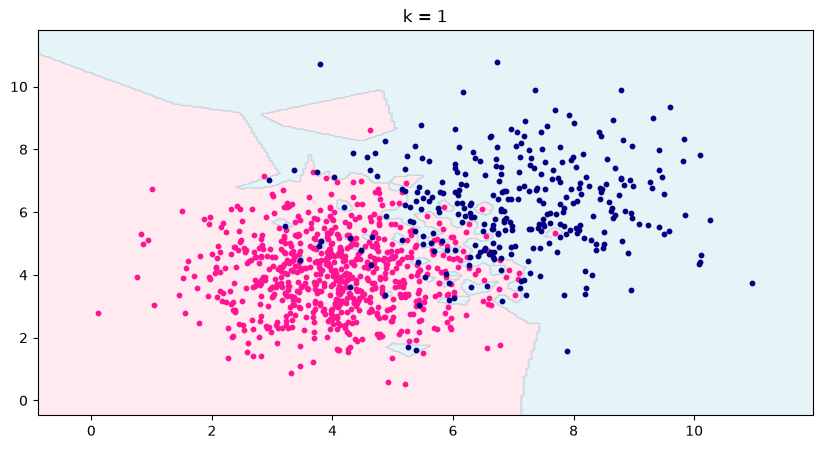

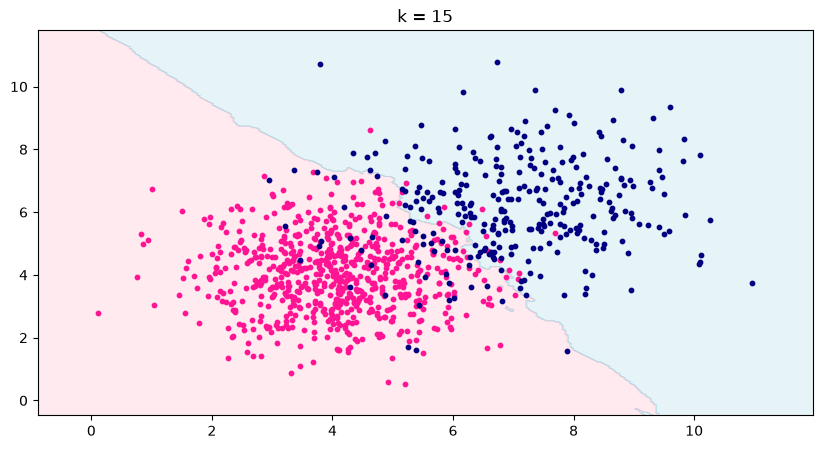

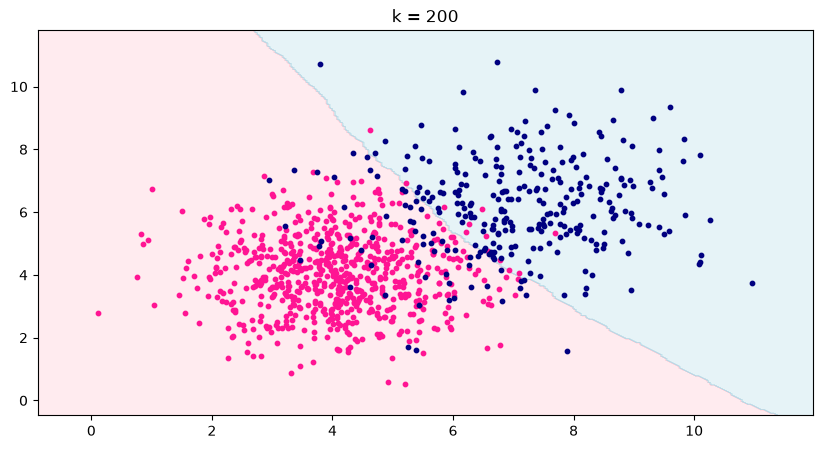

In [27]:
for k in [1, 15, 200]:
    m = KNeighborsClassifier(n_neighbors=k).fit(X2, y2)
    plot_decision_boundary(m, X2, y2, f"k = {k}")

## 🧠 Key takeaways

1. KNN is a **non-parametric** method: no assumption about the shape of the distributions.
2. The fraction of neighbors of each class is a **local estimate of the posterior** $P(\text{class}\mid x)$ — KNN approximates the Bayes optimal classifier from data.
3. **k controls smoothness**: small k → overfit, large k → underfit. Pick it with cross-validation.
4. Watch out: KNN needs **feature scaling** (distances!) and struggles in high dimensions (curse of dimensionality).